<h1> Simulated Annealing (SA) </h1>

Current Solution

        ↓

Generate Neighbor

        ↓

Evaluate Difference

        ↓

Accept or Reject

        ↓

Cool Temperature

        ↓

Repeat

Advantage: </br>
Escape from Local Optimum

Weakness:</br>
Need to set Cooling Schedule

Temperature actually acts as a controller:

High temperature:</br>
"I'm not sure yet, let me explore the environment"

Low temperature:</br>
"I almost figured out where it's good, optimize"

The main idea of ​​Simulated Annealing

Simulated Annealing says:

A bad move may be bad in the short term, but it will get us to a better place in the long term.

So unlike Hill Climbing:

Sometimes it accepts bad moves.

*The law of accepting bad moves*

$P=e^(−ΔE/T)​$

Cooling Schedule

We need to reduce the temperature.</br>
For example:</br>

$T_{new}= \alpha T$

Where:</br>
$0<α<1$

| Feature       | Hill Climbing | Simulated Annealing |
| ------------- | ------------- | ------------------- |
| Bad move      | Always rejected | Sometimes accepted |
| Exploration   | Low            | A lot               |
| Temperature   | No             | Yes                 |
| Randomness    | Low            | A lot               |
| Local optimum | Problem        | Less                |


In Simulated Annealing we have three very important parameters:

1) Initial Temperature</br>
(How much initial exploration to do.)</br>
High: Explore more</br>
Low: Early exploitation

2) Cooling Rate</br>
For example:</br>
If: $\alpha=0.99$</br>
then: Slow cooling.</br>
If: $\alpha=0.5$</br>
then: Fast cooling.

3) Minimum Temperature</br>
(Stopping condition.)</br>
For example:</br>
while T > 0.001:

| Algorithm           | How does it solve the Local Optimum problem? |
| ------------------- | -------------------------------------- |
| Hill Climbing       | It doesn't solve.                      |
| Random Restart HC   | With new beginnings                    |
| Simulated Annealing | By accepting the bad move              |


In [1]:
import math
import matplotlib.pyplot as plt

from src.simulated_annealing import (
    acceptance_probability,
    simulated_annealing,
    random_neighbor,
    simulated_annealing_with_best,
    bounded_random_neighbor,
    simulated_annealing_with_history
)
from src.hill_climbing import (
    hill_climbing, 
    random_restart_hill_climbing,
    get_neighbors
)

<h3> Step 1: Manual test of acceptance probability function with T criterion </h3>

In [2]:
print(
    acceptance_probability(
        100,
        90,
        100,
    )
)

0.9048374180359595


In [3]:
print(
    acceptance_probability(
        100,
        90,
        0.1,
    )
)

3.720075976020836e-44


$3.72×10^(−44)$

<h3> Step 2: Building the main algorithm </h3>

For SA, unlike Hill Climbing:</br>
It is better for the Neighbor function to only give one neighbor.

Because SA:</br>
does not check all neighbors.</br>
Rather:</br>
it tries a random move.

In [4]:
def multimodal_function(x):
    return math.sin(x) + 0.1*x

In [5]:
solution = simulated_annealing(
    multimodal_function,
    initial_state=1,
    get_neighbor=random_neighbor,
    initial_temperature=100,
    cooling_rate=0.95,
    minimum_temperature=0.01,
)

print(solution)

print(
    multimodal_function(solution)
)

7.933722411670254
1.7901946296498805


In [6]:
for i in range(5):
    solution = simulated_annealing(
        multimodal_function,
        initial_state=1,
        get_neighbor=random_neighbor,
        initial_temperature=100,
        cooling_rate=0.95,
        minimum_temperature=0.01,
    )
    print(
        solution,
        multimodal_function(solution)
    )

7.99888538197084 1.7894083471717153
8.028038728484491 1.7876941415020906
1.8251661804452244 1.1503386731240473
1.6508498820320816 1.1618824132259444
8.077231988834207 1.782906170667663


<h3> Step 3: Test with limited neighbors </h3>

In [7]:
for i in range(5):

    solution = simulated_annealing_with_best(
        multimodal_function,
        initial_state=1,
        get_neighbor=bounded_random_neighbor,
        initial_temperature=100,
        cooling_rate=0.99,
        minimum_temperature=0.01,
    )

    print(
        solution,
        multimodal_function(solution),
    )

20 2.9129452507276277
20 2.9129452507276277
14.236756981926865 2.418720707486437
7.270145857388379 1.5613689899173422
14.242489757348658 2.4187076532143625


<h3> Step 4: Comparison of the effect of cooling rate. </h3>

In [8]:
cooling_rates = [
    0.90,
    0.95,
    0.99,
]

for cooling_rate in cooling_rates:
    print(
        f"\nCooling Rate: {cooling_rate}"
    )
    for i in range(5):
        solution = simulated_annealing_with_best(
            multimodal_function,
            initial_state=1,
            get_neighbor=bounded_random_neighbor,
            initial_temperature=100,
            cooling_rate=cooling_rate,
            minimum_temperature=0.01,
        )
        print(
            round(solution, 4),
            round(
                multimodal_function(solution),
                4,
            ),
        )


Cooling Rate: 0.9
1.6808 1.162
1.633 1.1614
1.6761 1.1621
7.9543 1.7904
1.6916 1.1619

Cooling Rate: 0.95
7.9329 1.7902
1.671 1.1621
7.9618 1.7904
1.6885 1.1619
1.6776 1.1621

Cooling Rate: 0.99
7.954 1.7904
14.2356 2.4187
1.6703 1.1621
20 2.9129
7.9538 1.7904


<h3> Step 5: Adding History </h3>

In [9]:
solution, history = simulated_annealing_with_history(
    multimodal_function,
    initial_state=1,
    get_neighbor=bounded_random_neighbor,
    initial_temperature=100,
    cooling_rate=0.99,
    minimum_temperature=0.01,
)

solution

7.956875503363465

In [10]:
multimodal_function(solution)

1.790398644830825

In [11]:
history

[{'temperature': 100,
  'current_value': 0.08146926538570992,
  'best_value': 0.9414709848078965},
 {'temperature': 99.0, 'current_value': 0.0, 'best_value': 0.9414709848078965},
 {'temperature': 98.01,
  'current_value': 0.8609000254831758,
  'best_value': 0.9414709848078965},
 {'temperature': 97.0299,
  'current_value': 0.994108613558549,
  'best_value': 0.994108613558549},
 {'temperature': 96.059601,
  'current_value': 1.144785356664652,
  'best_value': 1.144785356664652},
 {'temperature': 95.09900499,
  'current_value': 0.841481824562532,
  'best_value': 1.144785356664652},
 {'temperature': 94.1480149401,
  'current_value': 1.075272107398058,
  'best_value': 1.144785356664652},
 {'temperature': 93.206534790699,
  'current_value': 1.0854672633025149,
  'best_value': 1.144785356664652},
 {'temperature': 92.27446944279201,
  'current_value': 1.1532309014330409,
  'best_value': 1.1532309014330409},
 {'temperature': 91.35172474836409,
  'current_value': 1.085448113652519,
  'best_value'

In [12]:
best_values = [
    item["best_value"]
    for item in history
]

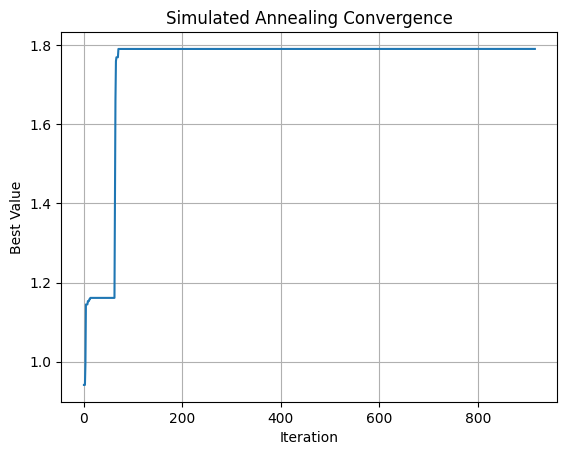

In [13]:
plt.plot(
    best_values
)

plt.xlabel(
    "Iteration"
)

plt.ylabel(
    "Best Value"
)

plt.title(
    "Simulated Annealing Convergence"
)

plt.grid()

plt.show()

<h3> Step 6: Comparison of Algorithms (HC, Random Restart HC, SA) </h3>
A standard test

In [14]:
results = {}

hc_solution = hill_climbing(
    multimodal_function,
    1,
    get_neighbors,
)

results["Hill Climbing"] = (
    multimodal_function(hc_solution)
)

rr_solution = random_restart_hill_climbing(
    multimodal_function,
    get_neighbors,
    (0,20),
    restarts=20,
)

results["Random Restart"] = (
    multimodal_function(rr_solution)
)

sa_solution, _ = simulated_annealing_with_history(
    multimodal_function,
    1,
    bounded_random_neighbor,
    100,
    0.99,
    0.01,
)

results["Simulated Annealing"] = (
    multimodal_function(sa_solution)
)

In [15]:
results

{'Hill Climbing': 1.1092974268256817,
 'Random Restart': 3.0466806636104904,
 'Simulated Annealing': 1.6007993370411646}

SA is highly sensitive to the following parameters:

Initial Temperature</br>
Cooling Rate</br>
Minimum Temperature

Algorithms involve trade-offs.


| Algorithm         | Exploration        | Exploitation |
| ----------------- | ------------------ | ------------ |
| Hill Climbing     | Low                 | A lot         |
| Random Restart HC | A lot (between Starts) | A lot         |
| SA                | Medium/A lot         | Medium        |



However, regarding our benchmark:

The function</br>
$f(x)=\sin(x)+0.1x$

was chosen for educational purposes. </br>
But it has a drawback for serious comparison:</br>
The global optimum lies near the boundary:</br>
$x=20$

Consequently, "Random Restart" has a good chance of success, as it only needs to start near the end of the interval.

For a better benchmark, we typically use standard functions:</br>
For Example: </br>

1. Rastrigin Function:</br>
$f(x)=10n+\sum(x_i^2-10cos(2\pi x_i))$

2. Ackley Function

Random Restart Hill Climbing improves exploration by repeatedly starting from different initial points. Simulated Annealing provides exploration through probabilistic acceptance of worse solutions, but its performance strongly depends on temperature scheduling and neighborhood design.